# Step 2: Exploratory Data Analysis (EDA) 
# 探索性數據分析

Visualizing data is crucial to identify patterns and outliers before inference:
1. **Proportion EDA**: Use a count plot to show the frequency of cigarette use.
2. **Continuous EDA**: Use a histogram for distribution shape and a boxplot for outlier detection in `BMIPCT`.
3. **Storage**: All plots are saved to `outputs/figures/`.


在推論之前，視覺化數據對於識別模式與異常值至關重要：
1. **比例分析 EDA**：使用計數圖顯示吸菸行為的頻率。
2. **連續變數 EDA**：使用直方圖觀察分佈形狀，並透過箱形圖檢測 `BMIPCT` 的異常值。
3. **儲存**：所有圖表均存儲至 `outputs/figures/`。

## 2.1 Behavior Variable: Proportional Composition and Stability 
## 行為變數：比例組成與穩定性分析



### 2.1.1 Frequency Tables and Recoding Summary 次數表與重編碼摘要

In [1]:
import pandas as pd
import numpy as np

# 載入資料
df_raw = pd.read_csv('../data/raw/YRBS_2007.csv')
df_recoded = pd.read_csv('../data/processed/yrbs_recoded.csv')

# 1. 原始代碼次數表 (包含缺失值 NaN)
print("Table 1: Original Code Frequencies (EverCigaretteUse)")
orig_counts = df_raw['EverCigaretteUse'].value_counts(dropna=False).sort_index()
print(orig_counts)

# --- 新增：計算原始資料的有效筆數 ---
raw_valid_n = df_raw['EverCigaretteUse'].dropna().count()
print(f"Total Valid N in Raw Data: {raw_valid_n}")

# 2. 缺失與無效值統計 (Missing/Invalid Count)
missing_val = df_raw['EverCigaretteUse'].isnull().sum()
invalid_val = len(df_raw[(df_raw['EverCigaretteUse'] != 1) & (df_raw['EverCigaretteUse'] != 2) & (df_raw['EverCigaretteUse'].notnull())])
print(f"\nMissing values: {missing_val}")
print(f"Invalid values (other than 1 or 2): {invalid_val}")

# 3. 重編碼後的次數與比例 (Success and Failure)
print("\nTable 2: Binary Recoding Summary (1=Success, 0=Failure)")
counts = df_recoded['EverCig_Binary'].value_counts()
proportions = df_recoded['EverCig_Binary'].value_counts(normalize=True)

# --- 新增：計算重編碼後的總有效筆數 ---
recoded_valid_n = counts.sum()

summary_table = pd.concat([counts, proportions], axis=1, keys=['Counts', 'Proportions'])
print(summary_table)
print(f"\nTotal Valid N in Recoded Data: {recoded_valid_n}")

Table 1: Original Code Frequencies (EverCigaretteUse)
EverCigaretteUse
1.0    7164
2.0    6437
NaN     440
Name: count, dtype: int64
Total Valid N in Raw Data: 13601

Missing values: 440
Invalid values (other than 1 or 2): 0

Table 2: Binary Recoding Summary (1=Success, 0=Failure)
                Counts  Proportions
EverCig_Binary                     
1                 6706     0.528739
0                 5977     0.471261

Total Valid N in Recoded Data: 12683


**Observations (Table 1: Original Distribution):**
* **Raw Data Composition**: The initial audit of `EverCigaretteUse` reveals that **7,164** students reported having tried cigarettes (Code 1), while **6,437** reported they had not (Code 2).
* **Missing & Invalid Values**: There are **440** missing values (NaN) in the original dataset. Crucially, the invalid value count is **0**, meaning all recorded entries follow the expected "1 or 2" coding scheme, ensuring high data quality for the next steps.


* **原始數據組成**：`EverCigaretteUse` 的初步稽核顯示，有 **7,164** 名學生報告曾嘗試吸菸（代碼 1），**6,437** 名學生報告未曾嘗試（代碼 2）。
* **缺失與無效值**：原始數據中存在 **440** 筆缺失值 (NaN)。關鍵的是，無效值數量為 **0**，這表示所有記錄的條目都符合預期的「1 或 2」編碼方案，確保了後續步驟的高數據質量。

---

**Observations (Table 2: Binary Recoding & Success Rate):**
* **Sample Size After Cleaning**: After performing listwise deletion (removing students who missed either the smoking or BMI questions), the total sample size for analysis is **12,683**.
* **Success vs. Failure**: 
    * **Success (1)**: **6,706** students (**52.87%**) have ever tried smoking.
    * **Failure (0)**: **5,977** students (**47.13%**) have never tried smoking.
* **Proportion Insight**: The sample proportion ($\hat{p} \approx 0.529$) is higher than 0.50, providing preliminary evidence that more than half of the adolescent population in this 2007 survey had experimented with cigarettes.


* **清理後樣本量**：在執行列表刪除法（移除未回答吸菸或 BMI 問題的學生）後，用於分析的總樣本量為 **12,683**。
* **成功與失敗**：
    * **成功 (1)**：**6,706** 名學生 (**52.87%**) 曾嘗試吸菸。
    * **失敗 (0)**：**5,977** 名學生 (**47.13%**) 未曾嘗試吸菸。
* **比例洞察**：樣本比例 ($\hat{p} \approx 0.529$) 高於 0.50，這提供了初步證據，顯示在 2007 年的這項調查中，超過一半的青少年曾嘗試過吸菸。

### 2.1.2 Visual Analysis of Cigarette Use 吸菸行為視覺化分析
We examine the distribution of cigarette use through a combined visualization approach. Furthermore, we apply **Bootstrap Resampling** to verify the stability of our sample proportion and its position relative to the null hypothesis.


我們透過組合視覺化方法檢查吸菸行為的分佈。此外，我們應用 **Bootstrap 重抽樣**來驗證樣本比例的穩定性及其相對於虛無假設的位置。

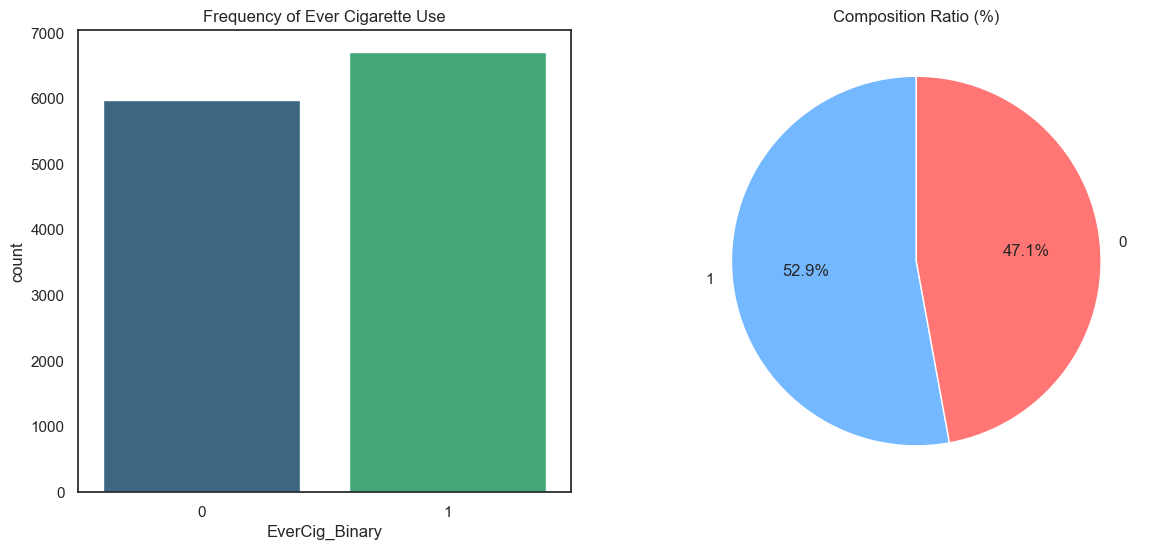

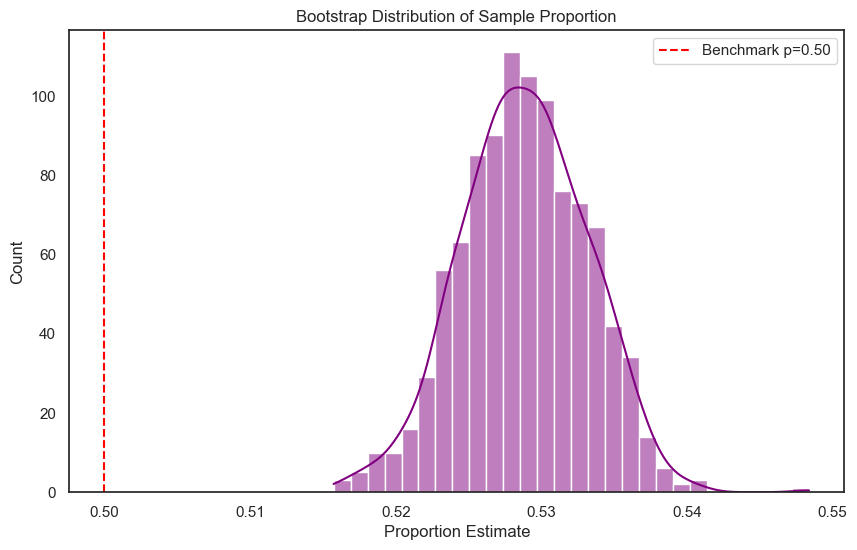

In [1]:
import pandas as pd  
import seaborn as sns
import matplotlib.pyplot as plt

# 確保路徑正確
df = pd.read_csv('../data/processed/yrbs_recoded.csv')
sns.set_theme(style="white")

# Visualization 1
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Bar Chart - 修正了 palette 的警告問題
sns.countplot(
    x='EverCig_Binary', 
    data=df, 
    ax=ax[0], 
    hue='EverCig_Binary',   # 指定 hue
    palette='viridis', 
    legend=False            # 隱藏重複的圖例
)
ax[0].set_title('Frequency of Ever Cigarette Use')
ax[0].set_ylabel('count')

# Pie Chart
df['EverCig_Binary'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    ax=ax[1], 
    colors=['#74b9ff','#ff7675'], 
    startangle=90
)
ax[1].set_ylabel('')
ax[1].set_title('Composition Ratio (%)')

plt.savefig('../outputs/figures/behavior_composition.png')
plt.show()

# Visualization 2: Bootstrap Distribution
# 注意：確保 'EverCig_Binary' 是數值型態 (0, 1) 才能計算 .mean()
boot_means = [df['EverCig_Binary'].sample(frac=1, replace=True).mean() for _ in range(1000)]

plt.figure(figsize=(10, 6))
sns.histplot(boot_means, kde=True, color='purple')
plt.axvline(0.50, color='red', linestyle='--', label='Benchmark p=0.50')
plt.title('Bootstrap Distribution of Sample Proportion')
plt.xlabel('Proportion Estimate')
plt.legend()
plt.savefig('../outputs/figures/behavior_bootstrap.png')
plt.show()

### Interpretation of Behavior Visuals 
### 行為變數視覺化解釋

* **Composition Analysis (Figure 1)**: The bar chart and pie chart reveal that 52.9% of the students have tried smoking, while 47.1% have not. This confirms that the majority of the sampled adolescent population in 2007 had experimented with cigarettes.
* **Bootstrap Stability (Figure 2)**: The resampling distribution is centered at approximately 0.529, clearly positioned to the **right** of the red benchmark line ($p=0.50$).
* **Statistical Implication**: Since the entire distribution (including the tails) lies above 0.50, we have strong visual evidence that the true population proportion is significantly higher than 50%. This suggests that experimentation with smoking was more common than not among the youth surveyed.

* **組成分析（圖一）**：長條圖與圓餅圖顯示 52.9% 的學生曾嘗試過吸菸，而 47.1% 則沒有。這確認了在 2007 年抽樣的青少年群體中，大多數人都有過吸菸的經驗。
* **Bootstrap 穩定性（圖二）**：重抽樣分佈中心約為 0.529，清晰地定位在紅色基準線 ($p=0.50$) 的**右側**。
* **統計意義**：由於整個分佈（包括尾部）都位於 0.50 之上，我們有強大的視覺證據表明母體真實比例顯著高於 50%。這暗示在受訪青少年中，嘗試吸菸的行為比不嘗試更為普遍。

## 2.2 Continuous Variable: Distribution Diagnostics (BMIPCT)
##  連續變數：分佈診斷分析 (BMIPCT)


### 2.2.1 Descriptive Statistics & Data Audit  描述性統計與數據稽核

We first conduct a comprehensive numerical audit of the `BMIPCT` variable. This stage focuses on understanding the data's distribution through central tendency (mean, median), dispersion (standard deviation), and its full range (minimum, maximum, and quartiles). This provides the numerical foundation for identifying skewness and potential outliers.

首先對 `BMIPCT` 變數進行全面的數值稽核。此階段重點在於透過中心趨勢（平均值、中位數）、離散程度（標準差）及其完整範圍（最小值、最大值和四分位數）來了解數據分佈。為識別偏態和潛在異常值提供了數值基礎。

In [3]:
import pandas as pd

# 1. 載入數據
df = pd.read_csv('../data/processed/yrbs_recoded.csv')

# 2. 計算數值
stats_desc = df['BMIPCT'].describe()
median_val = df['BMIPCT'].median()
missing_count_bmi = 979 

# 3. 定義標籤與數值的對應
rows = [
    ("Sample Size (n)", len(df)),
    ("Missing Value Count", missing_count_bmi),
    ("Mean (平均值)", stats_desc['mean']),
    ("Median (中位數)", median_val),
    ("Standard Deviation (標準差)", stats_desc['std']),
    ("Minimum (最小值)", stats_desc['min']),
    ("25th Percentile (Q1)", stats_desc['25%']),
    ("50th Percentile (Q2/Median)", stats_desc['50%']),
    ("75th Percentile (Q3)", stats_desc['75%']),
    ("Maximum (最大值)", stats_desc['max'])
]

# 4. 使用格式化字串進行「右對齊」輸出
print(f"{'Detailed Descriptive Statistics for BMIPCT':^50}") # 標題置中
print("-" * 50)
print(f"{'Metric':>30} | {'Value':>15}") # 欄位名稱對齊
print("-" * 50)

for metric, value in rows:
    # {metric:>30} 代表 Metric 佔 30格且向右對齊
    # {value:>15.2f} 代表 Value 佔 15格、浮點數取兩位且向右對齊
    if isinstance(value, int):
        print(f"{metric:>30} | {value:>15}")
    else:
        print(f"{metric:>30} | {value:>15.2f}")
print("-" * 50)

    Detailed Descriptive Statistics for BMIPCT    
--------------------------------------------------
                        Metric |           Value
--------------------------------------------------
               Sample Size (n) |           12683
           Missing Value Count |             979
                    Mean (平均值) |           64.84
                  Median (中位數) |           70.15
      Standard Deviation (標準差) |           27.48
                 Minimum (最小值) |            0.00
          25th Percentile (Q1) |           45.17
   50th Percentile (Q2/Median) |           70.15
          75th Percentile (Q3) |           89.43
                 Maximum (最大值) |           99.94
--------------------------------------------------


**Observations:**
* **Sample Integrity**: The final analysis is based on **12,683** valid records after excluding **979** missing values.
* **Central Tendency**: The **Mean (64.84)** is lower than the **Median (70.15)**, which is a classic indicator of a **left-skewed** distribution.
* **Range**: The data covers the full theoretical range of percentiles from approximately **0 to 100**, with a Standard Deviation of **27.48**.
* **Quartile Distribution**: The gap between Q1 (45.17) and Q2 (70.15) is larger than the gap between Q2 and Q3 (89.43), indicating that data points are more spread out in the lower half and more densely packed in the upper half.

* **樣本完整性**：在排除 **979** 筆缺失值後，最終分析基於 **12,683** 筆有效記錄。
* **中心趨勢**：**平均值 (64.84)** 低於 **中位數 (70.15)**，這是 **左偏 (Left-Skewed)** 分佈的典型指標。
* **範圍**：數據涵蓋了百分位數從約 **0 到 100** 的完整理論範圍，標準差為 **27.48**。
* **四分位分佈**：Q1 (45.17) 與 Q2 (70.15) 之間的差距大於 Q2 與 Q3 (89.43) 之間的差距，顯示數據點在下半部較為分散，而在上半部則較為密集。



### 2.2.2 Visual Analysis: Histogram, Boxplot, and Q-Q Plot
### 視覺化分析：直方圖、箱形圖與 Q-Q 圖
We perform a three-panel diagnostic (Histogram, Boxplot, and Q-Q Plot) to evaluate the normality of the BMI Percentile variable and identify potential outliers.

執行三面板診斷分析（直方圖、箱形圖與 Q-Q 圖），以評估 BMI 百分位數變數的常態性並識別潛在的異常值。

### (1) Histogram and KDE / 直方圖與核密度估計

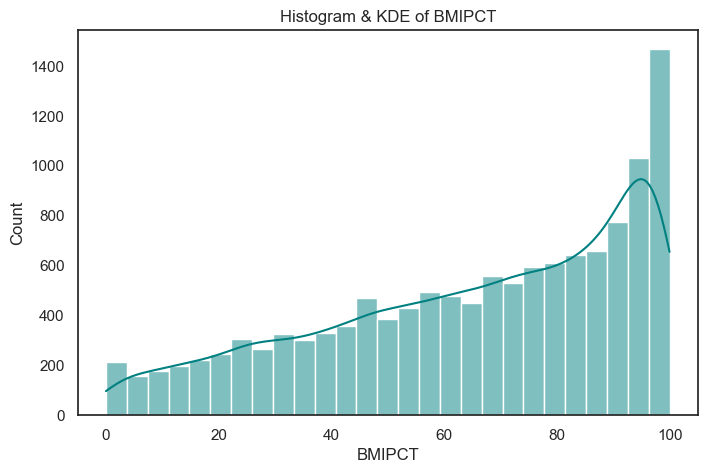

In [4]:
# 視覺化 3.1: 直方圖與 KDE (分開繪製)
plt.figure(figsize=(8, 5))
sns.histplot(df['BMIPCT'], kde=True, color='teal')
plt.title('Histogram & KDE of BMIPCT')
plt.xlabel('BMIPCT')
plt.ylabel('Count')
plt.savefig('../outputs/figures/continuous_histogram.png')
plt.show()

### (1) Interpretation: Histogram (Shape & Skewness) 直方圖（形狀與偏態）

* **Visual Observation**: The histogram shows a significant **left-skewed (negative skew)** distribution. The frequency of data points increases as the BMI percentile approaches 100.
* **Data Insight**: There is a massive spike in the high-percentile range (90-100), suggesting a high concentration of students in the upper BMI categories within this specific dataset.

* **視覺觀察**：直方圖顯示出顯著的**左偏（負偏態）**分佈。隨著 BMI 百分位數接近 100，數據點的頻率顯著增加。
* **數據洞察**：在高百分位區間（90-100）出現了巨大的峰值，這暗示在該數據集中，學生高度集中在較高的 BMI 類別。

### (2) Boxplot / 箱形圖

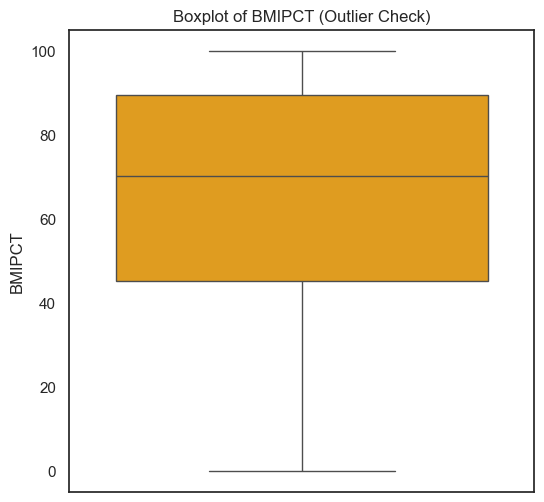

In [5]:
# 視覺化 3.2: 箱形圖 (分開繪製)
plt.figure(figsize=(6, 6))
sns.boxplot(y=df['BMIPCT'], color='orange')
plt.title('Boxplot of BMIPCT (Outlier Check)')
plt.ylabel('BMIPCT')
plt.savefig('../outputs/figures/continuous_boxplot.png')
plt.show()

### (2) Interpretation: Boxplot (Quartiles & Outliers) 箱形圖（四分位數與異常值）

* **Quartile Positioning**: The median line (horizontal line inside the box) is positioned towards the upper part of the range (around 70). The box itself is stretched downwards, confirming the left-skewed nature.
* **Outlier Diagnostic**: There are no individual circles beyond the whiskers (0 and 100), indicating that even though the distribution is skewed, all data points fall within the valid percentile range without extreme statistical outliers.

* **四分位數定位**：中位數線（箱子內部的橫線）位於範圍的上部（約 70 附近）。箱體本身向下延伸，進一步確認了左偏的性質。
* **異常值診斷**：鬚線（0 與 100）之外沒有出現單獨的圓圈，這表明儘管分佈偏斜，所有數據點仍落在有效的百分位範圍內，沒有極端的統計異常值。

### (3) Normal Q-Q Plot / 常態 Q-Q 圖

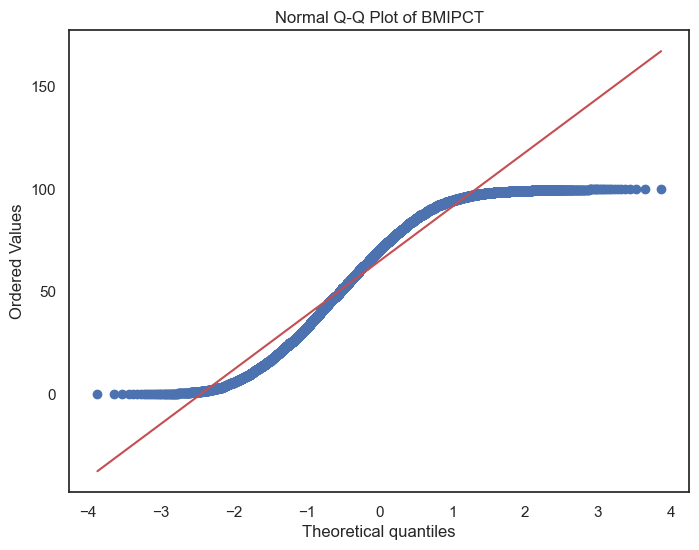

In [6]:
# 視覺化 3: 常態 Q-Q 圖 
from scipy import stats
plt.figure(figsize=(8, 6))
stats.probplot(df['BMIPCT'], plot=plt)
plt.title('Normal Q-Q Plot of BMIPCT')
plt.savefig('../outputs/figures/continuous_qqplot.png')
plt.show()

### (3) Interpretation: Normal Q-Q Plot (Normality Check) 常態 Q-Q 圖（常態性檢核）

* **Deviation from Normality**: The data points (blue dots) deviate significantly from the red reference line, especially at the lower and upper theoretical quantiles.
* **S-Curve Pattern**: The distinct "S" shape in the Q-Q plot is a classic indicator of a non-normal distribution. Given the large sample size, we must acknowledge that while a T-test might be robust, the underlying data is strongly non-normal, which is a critical finding for our report.

* **偏離常態性**：數據點（藍色點）顯著偏離了紅色基準線，特別是在理論分位數的低端和高端。
* **S 形模式**：Q-Q 圖中明顯的「S」形狀是典型的非常態分佈指標。鑑於樣本量較大，我們必須承認雖然 T 檢定可能具有穩健性，但底層數據呈現強烈的非常態性，這是報告中的關鍵發現。